In [8]:
%pip install ta-lib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 368 kB 5.5 MB/s eta 0:00:01
  distutils: /private/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/pip-build-env-mp08qq1z/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/pip-build-env-mp08qq1z/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = False
  home = None
  root = None
  prefix = '/private/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/pip-build-env-mp08qq1z/normal'
  distutils: /private/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/pip-build-env-mp08qq1z/overlay/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/pip-build-env-mp08qq1z/overlay/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = 

In [9]:
import pandas as pd

In [10]:
df = pd.read_csv('/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/simulation/stocks_df.csv')

Selected Stocks: ['TROW', 'CTRA', 'CDNS', 'MGM', 'PSX', 'F', 'ARE', 'IPG', 'ABNB', 'ECL', 'DPZ', 'INTC', 'BDX', 'RL', 'UPS', 'ANSS', 'VLTO', 'URI', 'ROP', 'HES', 'ALB', 'AON', 'CMCSA', 'ROK', 'XYL']

Portfolio Metrics:
Total Return: 12.89%
Annualized Return: 13.00%
Annualized Volatility: 15.98%
Sharpe Ratio: 0.69
Maximum Drawdown: -14.78%


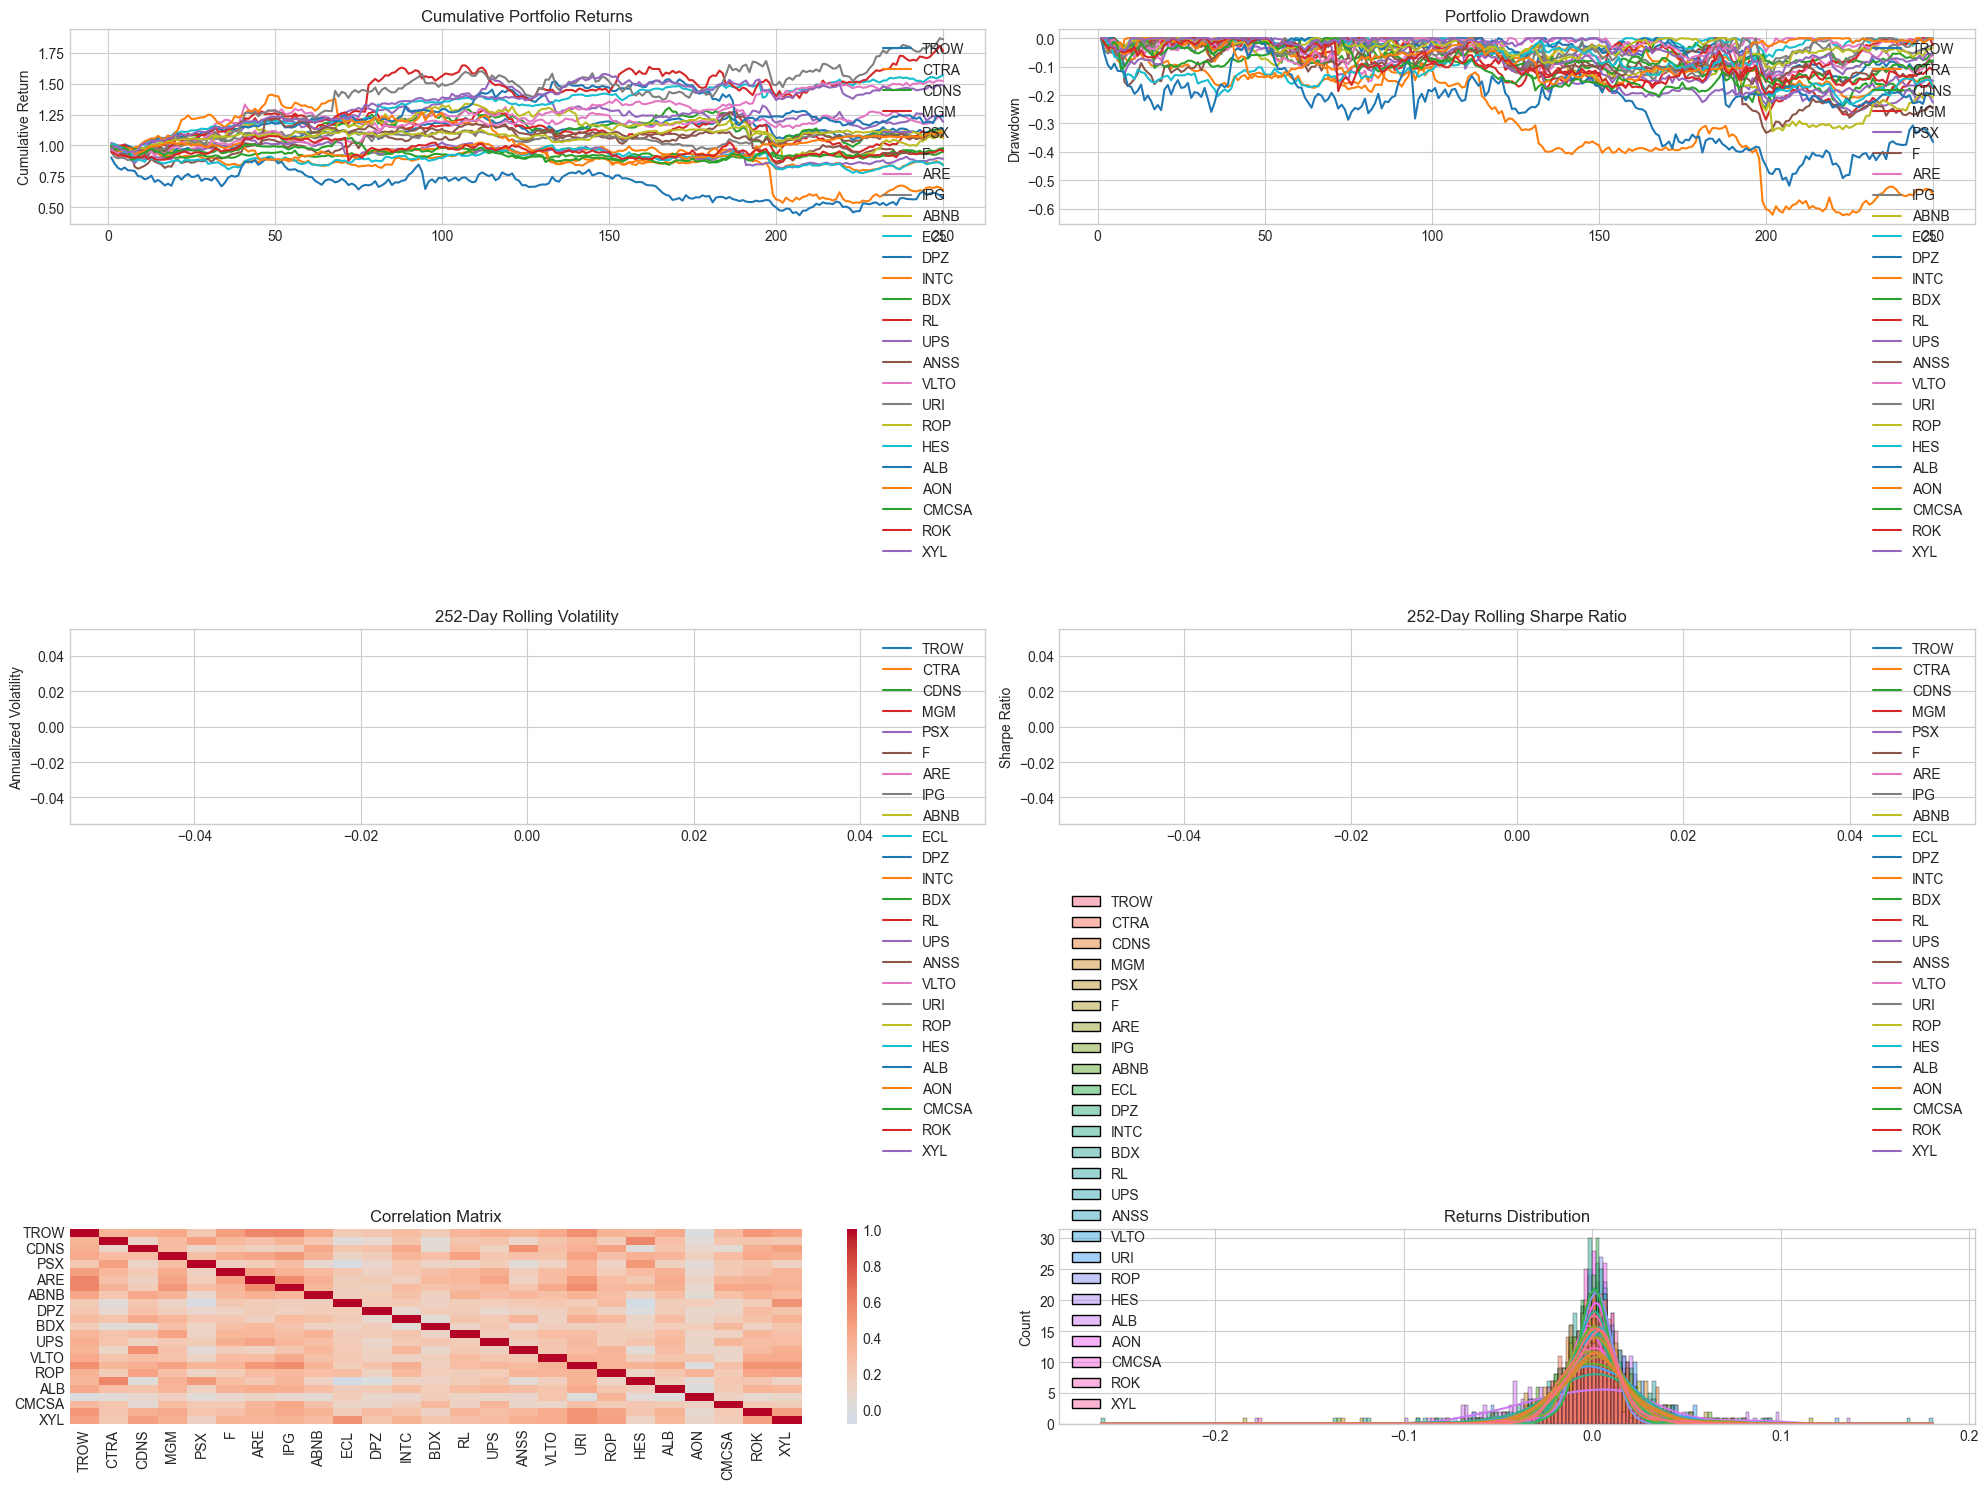

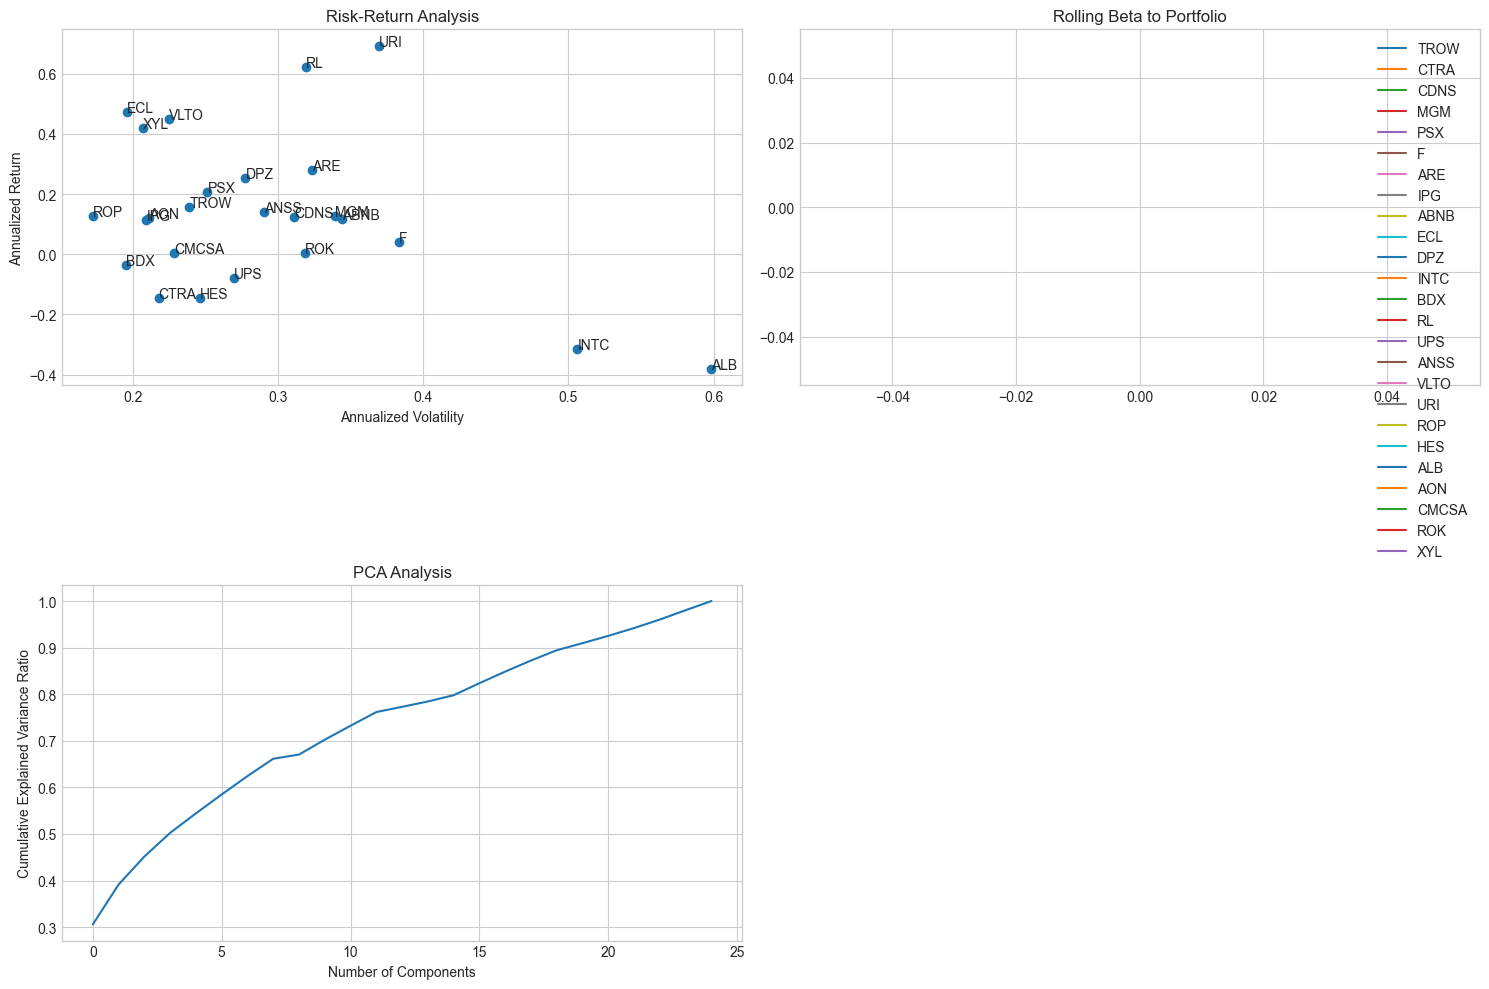

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def calculate_rsi(prices, period=14):
    """Calculate Relative Strength Index"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(prices, fast=12, slow=26, signal=9):
    """Calculate MACD"""
    exp1 = prices.ewm(span=fast, adjust=False).mean()
    exp2 = prices.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - signal_line
    return macd, signal_line, macd_hist

def calculate_bollinger_bands(prices, period=20, std_dev=2):
    """Calculate Bollinger Bands"""
    sma = prices.rolling(window=period).mean()
    rolling_std = prices.rolling(window=period).std()
    upper_band = sma + (rolling_std * std_dev)
    lower_band = sma - (rolling_std * std_dev)
    return upper_band, sma, lower_band

def calculate_atr(high, low, close, period=14):
    """Calculate Average True Range"""
    high_low = high - low
    high_close = np.abs(high - close.shift())
    low_close = np.abs(low - close.shift())
    
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    atr = true_range.rolling(period).mean()
    return atr

def calculate_obv(prices, volumes):
    """Calculate On Balance Volume"""
    price_change = prices.diff()
    obv = pd.Series(index=prices.index)
    obv.iloc[0] = 0
    
    for i in range(1, len(prices)):
        if price_change.iloc[i] > 0:
            obv.iloc[i] = obv.iloc[i-1] + volumes.iloc[i]
        elif price_change.iloc[i] < 0:
            obv.iloc[i] = obv.iloc[i-1] - volumes.iloc[i]
        else:
            obv.iloc[i] = obv.iloc[i-1]
    return obv

def calculate_technical_indicators(df, stock_col):
    """Calculate various technical indicators for stock selection"""
    price = df[stock_col]
    
    # Momentum Indicators
    rsi = calculate_rsi(price)
    macd, macd_signal, macd_hist = calculate_macd(price)
    
    # Trend Indicators
    sma_20 = price.rolling(window=20).mean()
    sma_50 = price.rolling(window=50).mean()
    
    # Volatility Indicators
    bb_upper, bb_middle, bb_lower = calculate_bollinger_bands(price)
    
    # Assuming high/low are not available, using close price with small variation
    high = price * 1.002
    low = price * 0.998
    atr = calculate_atr(high, low, price)
    
    # Volume Indicators (using dummy volume)
    dummy_volume = pd.Series(np.ones_like(price), index=price.index)
    obv = calculate_obv(price, dummy_volume)
    
    return pd.DataFrame({
        'price': price,
        'rsi': rsi,
        'macd': macd,
        'macd_hist': macd_hist,
        'sma_20': sma_20,
        'sma_50': sma_50,
        'bb_upper': bb_upper,
        'bb_lower': bb_lower,
        'atr': atr,
        'obv': obv
    })

def score_stock(indicators_df):
    """Score each stock based on technical indicators"""
    score = 0
    
    # Get the last valid values for each indicator
    last_values = indicators_df.iloc[-1]
    
    # RSI signals (oversold/overbought)
    rsi_value = last_values['rsi']
    if pd.notna(rsi_value) and 30 <= rsi_value <= 70:
        score += 1
    
    # MACD signals
    if pd.notna(last_values['macd_hist']) and last_values['macd_hist'] > 0:
        score += 1
    
    # Trend signals
    if pd.notna(last_values['sma_20']) and pd.notna(last_values['sma_50']):
        if last_values['sma_20'] > last_values['sma_50']:
            score += 1
    
    # Bollinger Bands signals
    if (pd.notna(last_values['bb_lower']) and 
        pd.notna(last_values['bb_upper']) and 
        pd.notna(last_values['price'])):
        if last_values['bb_lower'] <= last_values['price'] <= last_values['bb_upper']:
            score += 1
    
    # Volatility consideration
    recent_atr = indicators_df['atr'].iloc[-20:].mean()
    if pd.notna(recent_atr) and pd.notna(indicators_df['atr'].mean()):
        if recent_atr < indicators_df['atr'].mean():
            score += 1
    
    return score

def calculate_portfolio_performance(returns):
    """Calculate key portfolio performance metrics"""
    # Cumulative Returns
    cum_returns = (1 + returns).cumprod()
    total_return = cum_returns.iloc[-1] - 1
    
    # Annualized Return
    n_years = len(returns) / 252
    ann_return = (1 + total_return) ** (1/n_years) - 1
    
    # Volatility
    ann_vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio (assuming risk-free rate of 0.02)
    rf_rate = 0.02
    sharpe = (ann_return - rf_rate) / ann_vol
    
    # Maximum Drawdown
    rolling_max = cum_returns.expanding().max()
    drawdowns = cum_returns/rolling_max - 1
    max_drawdown = drawdowns.min()
    
    return {
        'total_return': total_return,
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown
    }

def plot_portfolio_analysis(returns_data, prices_data, selected_stocks):
    """Generate comprehensive portfolio analysis plots"""
    #plt.style.use('seaborn')
    plt.style.use("seaborn-v0_8-whitegrid")
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Cumulative Returns Plot
    ax1 = plt.subplot(3, 2, 1)
    cum_returns = (1 + returns_data).cumprod()
    cum_returns.plot(ax=ax1)
    ax1.set_title('Cumulative Portfolio Returns')
    ax1.set_ylabel('Cumulative Return')
    
    # 2. Drawdown Plot
    ax2 = plt.subplot(3, 2, 2)
    rolling_max = cum_returns.expanding().max()
    drawdowns = cum_returns/rolling_max - 1
    drawdowns.plot(ax=ax2)
    ax2.set_title('Portfolio Drawdown')
    ax2.set_ylabel('Drawdown')
    
    # 3. Rolling Volatility
    ax3 = plt.subplot(3, 2, 3)
    rolling_vol = returns_data.rolling(window=252).std() * np.sqrt(252)
    rolling_vol.plot(ax=ax3)
    ax3.set_title('252-Day Rolling Volatility')
    ax3.set_ylabel('Annualized Volatility')
    
    # 4. Rolling Sharpe Ratio
    ax4 = plt.subplot(3, 2, 4)
    rolling_return = returns_data.rolling(window=252).mean() * 252
    rolling_vol = returns_data.rolling(window=252).std() * np.sqrt(252)
    rolling_sharpe = (rolling_return - 0.02) / rolling_vol  # Assuming risk-free rate of 0.02
    rolling_sharpe.plot(ax=ax4)
    ax4.set_title('252-Day Rolling Sharpe Ratio')
    ax4.set_ylabel('Sharpe Ratio')
    
    # 5. Correlation Heatmap
    ax5 = plt.subplot(3, 2, 5)
    sns.heatmap(returns_data.corr(), ax=ax5, cmap='coolwarm', center=0)
    ax5.set_title('Correlation Matrix')
    
    # 6. Return Distribution
    ax6 = plt.subplot(3, 2, 6)
    sns.histplot(returns_data, ax=ax6, kde=True)
    ax6.set_title('Returns Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Additional Analysis Plots
    fig2 = plt.figure(figsize=(15, 10))
    
    # 7. Risk-Return Scatter Plot
    ax7 = plt.subplot(2, 2, 1)
    ann_returns = returns_data.mean() * 252
    ann_vols = returns_data.std() * np.sqrt(252)
    plt.scatter(ann_vols, ann_returns)
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    for i, stock in enumerate(selected_stocks):
        plt.annotate(stock, (ann_vols[i], ann_returns[i]))
    ax7.set_title('Risk-Return Analysis')
    
    # 8. Rolling Beta to Equal-Weighted Portfolio
    ax8 = plt.subplot(2, 2, 2)
    portfolio_returns = returns_data.mean(axis=1)
    rolling_window = 252
    rolling_beta = pd.DataFrame()
    
    for column in returns_data.columns:
        covariance = returns_data[column].rolling(window=rolling_window).cov(portfolio_returns)
        variance = portfolio_returns.rolling(window=rolling_window).var()
        rolling_beta[column] = covariance / variance
    
    rolling_beta.plot(ax=ax8)
    ax8.set_title('Rolling Beta to Portfolio')
    
    # 9. Principal Component Analysis
    ax9 = plt.subplot(2, 2, 3)
    scaler = StandardScaler()
    scaled_returns = scaler.fit_transform(returns_data)
    cov_matrix = np.cov(scaled_returns.T)
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    plt.plot(np.cumsum(explained_variance_ratio))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    ax9.set_title('PCA Analysis')
    
    plt.tight_layout()
    plt.show()

def main_analysis(df):
    """Main analysis function"""
    # 1. Select top 25 stocks
    stock_scores = {}
    
    for col in df.columns:
        if 'Closing_Price' in col:
            stock_name = col.replace('_Closing_Price', '')
            indicators = calculate_technical_indicators(df, col)
            score = score_stock(indicators)
            stock_scores[stock_name] = score
    
    # Select top 25 stocks
    selected_stocks = sorted(stock_scores.items(), key=lambda x: x[1], reverse=True)[:25]
    selected_stocks = [stock[0] for stock in selected_stocks]
    
    print("Selected Stocks:", selected_stocks)
    
    # 2. Create price and returns data for selected stocks
    price_data = pd.DataFrame()
    for stock in selected_stocks:
        price_data[stock] = df[f'{stock}_Closing_Price']
    
    returns_data = price_data.pct_change().dropna()
    
    # 3. Calculate portfolio metrics
    portfolio_metrics = calculate_portfolio_performance(returns_data.mean(axis=1))
    
    # 4. Print metrics
    print("\nPortfolio Metrics:")
    print(f"Total Return: {portfolio_metrics['total_return']:.2%}")
    print(f"Annualized Return: {portfolio_metrics['ann_return']:.2%}")
    print(f"Annualized Volatility: {portfolio_metrics['ann_vol']:.2%}")
    print(f"Sharpe Ratio: {portfolio_metrics['sharpe']:.2f}")
    print(f"Maximum Drawdown: {portfolio_metrics['max_drawdown']:.2%}")
    
    # 5. Generate plots
    plot_portfolio_analysis(returns_data, price_data, selected_stocks)

    return selected_stocks, returns_data, price_data

# Run the analysis
selected_stocks, returns_data, price_data = main_analysis(df)